In [1]:
!pip install -q fastapi uvicorn nest-asyncio pyngrok pandas numpy scikit-learn torch matplotlib
print("All packages installed.")

All packages installed.


In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.dpi"] = 120

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH  = "mashwara_programs_dataset_fixed.csv"   # <-- upload this file to Colab
MODEL_DIR  = Path("model_artifacts")
MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / "program_eligibility_nn.pt"
META_PATH  = MODEL_DIR / "program_eligibility_meta.json"

print(f"Model artifacts will be saved to: {MODEL_DIR.resolve()}")

Using device: cuda
Model artifacts will be saved to: /content/model_artifacts


In [3]:

# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Load & Explore Dataset
# ─────────────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv(DATA_PATH)

print("=" * 60)
print("📂  DATASET OVERVIEW")
print("=" * 60)
print(f"  Shape           : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"  Missing values  : {df_raw.isnull().sum().sum()}")
print(f"\n  Program levels  : {df_raw['program_level'].value_counts().to_dict()}")
print(f"  Countries       : {df_raw['country'].value_counts().to_dict()}")
print(f"  Degree types    : {sorted(df_raw['degree_type'].unique().tolist())}")
print(f"  Categories      : {sorted(df_raw['program_category'].unique().tolist())}")
print(f"\n  QS Rank range   : {df_raw['qs_rank'].min()} – {df_raw['qs_rank'].max()}")
print(f"  GPA req range   : {df_raw['min_gpa'].min()} – {df_raw['min_gpa'].max()}")
print(f"  IELTS req range : {df_raw['min_ielts_overall'].min()} – {df_raw['min_ielts_overall'].max()}")
print(f"  TOEFL req range : {df_raw['toefl_score'].min()} – {df_raw['toefl_score'].max()}")
print("=" * 60)

df_raw.head(3)

📂  DATASET OVERVIEW
  Shape           : 5,598 rows × 20 columns
  Missing values  : 0

  Program levels  : {'bachelors': 3032, 'masters': 2566}
  Countries       : {'UK': 2442, 'Germany': 1317, 'Australia': 999, 'Canada': 781, 'Qatar': 59}
  Degree types    : ['BA', 'BArch', 'BBA', 'BCom', 'BDes', 'BEd', 'BEng', 'BFA', 'BN', 'BPharm', 'BSc', 'LLB', 'LLM', 'MA', 'MArch', 'MBA', 'MDes', 'MEd', 'MEng', 'MFA', 'MPH', 'MSc']
  Categories      : ['architecture', 'arts', 'business', 'cs', 'education', 'engineering', 'health', 'law', 'science', 'social_science']

  QS Rank range   : 2 – 1201
  GPA req range   : 2.5 – 3.7
  IELTS req range : 5.5 – 7.0
  TOEFL req range : 68 – 110


,university_name,country,qs_rank,program_name,standardized_program_name,degree_type,program_level,program_category,program_duration_years,tuition_fee_usd,scholarship_available,min_ielts_overall,min_ielts_band,toefl_score,duolingo_score,min_gpa,gre_required,min_gre_score,work_experience_required,field_requirements
0,Imperial College London,UK,2,Bachelor of Science in Human Resource Management,Human Resource Management,BSc,bachelors,business,3.0,40000,No,6.0,6.5,95,115,3.4,0,0,0,No specific background required; Mathematics p...
1,Imperial College London,UK,2,Bachelor of Science in Marketing,Marketing,BSc,bachelors,business,3.0,40000,No,6.0,6.5,95,115,3.4,0,0,0,No specific background required; Mathematics p...
2,Imperial College London,UK,2,Bachelor of Science in Finance,Finance,BSc,bachelors,business,3.0,40000,No,6.0,6.5,95,115,3.4,0,0,0,No specific background required; Mathematics p...


In [4]:
# ── 4a. Clean ────────────────────────────────────────────────────────────────
df = df_raw.copy()
df["scholarship_available"] = df["scholarship_available"].map({"Yes": 1, "No": 0}).fillna(0).astype(int)

# ── 4b. Encode categoricals ──────────────────────────────────────────────────
CAT_COLS = ["country", "program_level", "program_category", "degree_type"]
encoders = {}

print("🔤 Label Encoding:")
for col in CAT_COLS:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
    print(f"   {col:<22}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# ── 4c. Synthetic training data generation ───────────────────────────────────
#
# The dataset contains PROGRAM REQUIREMENTS — not student outcomes.
# Strategy: simulate N student profiles and pair each with a random program.
# Label = 1 (eligible) if the student meets ALL of the program's requirements.
# This teaches the network to estimate eligibility probability, not just 0/1.
#
# ─────────────────────────────────────────────────────────────────────────────

np.random.seed(SEED)
N_SAMPLES = len(df) * 4   # ~22,000 (student, program) pairs

# Randomly pick a program for each synthetic student
prog_idx  = np.random.randint(0, len(df), N_SAMPLES)
prog_rows = df.iloc[prog_idx].reset_index(drop=True)

# Simulate student profiles using realistic normal distributions
stud_gpa      = np.clip(np.random.normal(3.10, 0.45, N_SAMPLES), 2.0, 4.0)
stud_ielts    = np.clip(np.random.normal(6.50, 0.70, N_SAMPLES), 4.5, 9.0)
stud_ielts_b  = np.clip(np.random.normal(6.20, 0.70, N_SAMPLES), 4.5, 9.0)
stud_toefl    = np.clip(np.random.normal(88,   18,   N_SAMPLES), 40,  120).astype(int)
stud_duolingo = np.clip(np.random.normal(105,  25,   N_SAMPLES), 55,  160).astype(int)
stud_gre      = np.clip(np.random.normal(308,  20,   N_SAMPLES), 260, 340).astype(int)
stud_work     = np.random.randint(0, 2, N_SAMPLES)

# ── Eligibility rules ─────────────────────────────────────────────────────────
ok_gpa   = stud_gpa      >= prog_rows["min_gpa"].values
ok_ielts = stud_ielts    >= prog_rows["min_ielts_overall"].values
ok_ieltsb= stud_ielts_b  >= prog_rows["min_ielts_band"].values
ok_toefl = stud_toefl    >= prog_rows["toefl_score"].values
ok_gre   = (prog_rows["gre_required"].values == 0) | (stud_gre >= prog_rows["min_gre_score"].values)
ok_work  = (prog_rows["work_experience_required"].values == 0) | (stud_work == 1)

eligible = (ok_gpa & ok_ielts & ok_ieltsb & ok_toefl & ok_gre & ok_work).astype(int)

pos_rate = eligible.mean()
print(f"\n📊 Synthetic dataset: {N_SAMPLES:,} pairs")
print(f"   Eligible (1) : {eligible.sum():,} ({pos_rate:.1%})")
print(f"   Not eligible (0): {(eligible == 0).sum():,} ({1 - pos_rate:.1%})")

# ── 4d. Build training DataFrame ─────────────────────────────────────────────
TRAIN_FEATURE_COLS = [
    # Student profile
    "student_gpa", "student_ielts", "student_ielts_b",
    "student_toefl", "student_duolingo", "student_gre", "has_work_exp",
    # Program requirements
    "min_gpa", "min_ielts_overall", "min_ielts_band",
    "toefl_score", "duolingo_score",
    "gre_required", "min_gre_score",
    "work_experience_required",
    "program_duration_years",
    "tuition_fee_usd",
    "qs_rank",
    # Encoded categoricals
    "country_enc", "program_level_enc",
    "program_category_enc", "degree_type_enc",
    # Gap features — key signal for probability calibration
    "gpa_gap", "ielts_gap", "toefl_gap",
]

train_df = pd.DataFrame({
    "student_gpa"               : stud_gpa,
    "student_ielts"             : stud_ielts,
    "student_ielts_b"           : stud_ielts_b,
    "student_toefl"             : stud_toefl,
    "student_duolingo"          : stud_duolingo,
    "student_gre"               : stud_gre,
    "has_work_exp"              : stud_work,
    "min_gpa"                   : prog_rows["min_gpa"].values,
    "min_ielts_overall"         : prog_rows["min_ielts_overall"].values,
    "min_ielts_band"            : prog_rows["min_ielts_band"].values,
    "toefl_score"               : prog_rows["toefl_score"].values,
    "duolingo_score"            : prog_rows["duolingo_score"].values,
    "gre_required"              : prog_rows["gre_required"].values,
    "min_gre_score"             : prog_rows["min_gre_score"].values,
    "work_experience_required"  : prog_rows["work_experience_required"].values,
    "program_duration_years"    : prog_rows["program_duration_years"].values,
    "tuition_fee_usd"           : prog_rows["tuition_fee_usd"].values,
    "qs_rank"                   : prog_rows["qs_rank"].values,
    "country_enc"               : prog_rows["country_enc"].values,
    "program_level_enc"         : prog_rows["program_level_enc"].values,
    "program_category_enc"      : prog_rows["program_category_enc"].values,
    "degree_type_enc"           : prog_rows["degree_type_enc"].values,
    "gpa_gap"                   : stud_gpa    - prog_rows["min_gpa"].values,
    "ielts_gap"                 : stud_ielts  - prog_rows["min_ielts_overall"].values,
    "toefl_gap"                 : stud_toefl  - prog_rows["toefl_score"].values,
    "eligible"                  : eligible,
})

print(f"\n✅ Training DataFrame shape: {train_df.shape}")
print(f"   Features: {len(TRAIN_FEATURE_COLS)}")
train_df[TRAIN_FEATURE_COLS].describe().T[["mean", "min", "max"]].round(3)

🔤 Label Encoding:
   country               : {'Australia': np.int64(0), 'Canada': np.int64(1), 'Germany': np.int64(2), 'Qatar': np.int64(3), 'UK': np.int64(4)}
   program_level         : {'bachelors': np.int64(0), 'masters': np.int64(1)}
   program_category      : {'architecture': np.int64(0), 'arts': np.int64(1), 'business': np.int64(2), 'cs': np.int64(3), 'education': np.int64(4), 'engineering': np.int64(5), 'health': np.int64(6), 'law': np.int64(7), 'science': np.int64(8), 'social_science': np.int64(9)}
   degree_type           : {'BA': np.int64(0), 'BArch': np.int64(1), 'BBA': np.int64(2), 'BCom': np.int64(3), 'BDes': np.int64(4), 'BEd': np.int64(5), 'BEng': np.int64(6), 'BFA': np.int64(7), 'BN': np.int64(8), 'BPharm': np.int64(9), 'BSc': np.int64(10), 'LLB': np.int64(11), 'LLM': np.int64(12), 'MA': np.int64(13), 'MArch': np.int64(14), 'MBA': np.int64(15), 'MDes': np.int64(16), 'MEd': np.int64(17), 'MEng': np.int64(18), 'MFA': np.int64(19), 'MPH': np.int64(20), 'MSc': np.int64(21)}

,mean,min,max
student_gpa,3.097,2.0,4.000
student_ielts,6.502,4.5,9.000
student_ielts_b,6.206,4.5,8.832
student_toefl,87.261,40.0,120.000
student_duolingo,104.692,55.0,160.000
student_gre,307.135,260.0,340.000
has_work_exp,0.498,0.0,1.000
min_gpa,2.833,2.5,3.700
min_ielts_overall,6.001,5.5,7.000
min_ielts_band,6.470,5.5,7.500


In [5]:
X = train_df[TRAIN_FEATURE_COLS].values.astype(np.float32)
y = train_df["eligible"].values.astype(np.float32)

# 70 / 15 / 15 stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f"{'Split':<8} {'Shape':<20} {'Positive Rate'}")
print("-" * 45)
print(f"{'Train':<8} {str(X_train.shape):<20} {y_train.mean():.2%}")
print(f"{'Val':<8} {str(X_val.shape):<20} {y_val.mean():.2%}")
print(f"{'Test':<8} {str(X_test.shape):<20} {y_test.mean():.2%}")

# ── Scale — fit ONLY on train ─────────────────────────────────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"\n✅ StandardScaler fitted on train set.")

# ── PyTorch DataLoaders ───────────────────────────────────────────────────────
def make_loader(X_arr, y_arr, batch_size=512, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X_arr, dtype=torch.float32),
        torch.tensor(y_arr, dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   shuffle=False)
test_loader  = make_loader(X_test,  y_test,  shuffle=False)

print(f"✅ DataLoaders ready — batches per epoch: {len(train_loader)}")

Split    Shape                Positive Rate
---------------------------------------------
Train    (15674, 25)          17.14%
Val      (3359, 25)           17.15%
Test     (3359, 25)           17.12%

✅ StandardScaler fitted on train set.
✅ DataLoaders ready — batches per epoch: 31


In [6]:
class ProgramEligibilityNet(nn.Module):
    """
    Feed-forward neural network for program eligibility prediction.

    Input  →  FC(256) → BN → ReLU → Dropout(0.3)
           →  FC(128) → BN → ReLU → Dropout(0.3)
           →  FC(64)  → BN → ReLU → Dropout(0.2)
           →  FC(32)  → ReLU
           →  FC(1)   → Sigmoid

    BatchNorm: stabilises training across features with very different scales
               (e.g. tuition_fee_usd vs ielts_gap).
    Dropout  : prevents overfitting and yields better-calibrated probabilities.
    Gap feats: gpa_gap, ielts_gap, toefl_gap are the strongest eligibility signals.
    """

    def __init__(self, input_dim: int, dropout1: float = 0.3, dropout2: float = 0.2):
        super().__init__()
        self.network = nn.Sequential(
            # Block 1
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout1),
            # Block 2
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout1),
            # Block 3
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout2),
            # Block 4
            nn.Linear(64, 32),
            nn.ReLU(),
            # Output
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x).squeeze(1)


INPUT_DIM = X_train.shape[1]
model = ProgramEligibilityNet(INPUT_DIM).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Model built — Input dim: {INPUT_DIM}  |  Parameters: {total_params:,}")
print(model)

✅ Model built — Input dim: 25  |  Parameters: 50,817
ProgramEligibilityNet(
  (network): Sequential(
    (0): Linear(in_features=25, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): ReLU()
    (14): Linear(in_features=32, out_features=1, bias=True)
    (15): Sigmoid()
  )
)


In [7]:
# ── Loss & Optimizer ──────────────────────────────────────────────────────────
pos_count      = int(y_train.sum())
neg_count      = int(len(y_train) - pos_count)
pos_weight_val = neg_count / pos_count
criterion      = nn.BCELoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=5, factor=0.5   # ← verbose removed
)

print(f"Class balance — Positive: {pos_count:,} | Negative: {neg_count:,} | Ratio: {pos_weight_val:.2f}x")


def run_epoch(loader, is_train: bool):
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_probs, all_labels = [], []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            if is_train:
                optimizer.zero_grad()
            preds = model(xb)
            loss  = criterion(preds, yb)
            if is_train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * len(yb)
            all_probs.extend(preds.detach().cpu().numpy().tolist())
            all_labels.extend(yb.cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    auc      = roc_auc_score(all_labels, all_probs)
    return avg_loss, auc


# ── Training loop ─────────────────────────────────────────────────────────────
EPOCHS       = 60
best_val_auc = 0.0
history      = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": []}

print(f"\n{'Epoch':>5}  {'Train Loss':>11}  {'Train AUC':>10}  {'Val Loss':>9}  {'Val AUC':>9}  {'LR':>8}")
print("─" * 65)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_auc = run_epoch(train_loader, is_train=True)
    vl_loss, vl_auc = run_epoch(val_loader,   is_train=False)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_auc"].append(tr_auc)
    history["val_auc"].append(vl_auc)

    scheduler.step(vl_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    if vl_auc > best_val_auc:
        best_val_auc = vl_auc
        torch.save(model.state_dict(), MODEL_PATH)

    if epoch % 5 == 0 or epoch == 1:
        marker = " ◀ best" if vl_auc == best_val_auc else ""
        print(f"{epoch:>5}  {tr_loss:>11.5f}  {tr_auc:>10.4f}  "
              f"{vl_loss:>9.5f}  {vl_auc:>9.4f}  {current_lr:>8.6f}{marker}")

print(f"\n✅ Training complete — Best Val AUC: {best_val_auc:.4f}")
print(f"   Model saved to: {MODEL_PATH}")

Class balance — Positive: 2,687 | Negative: 12,987 | Ratio: 4.83x

Epoch   Train Loss   Train AUC   Val Loss    Val AUC        LR
─────────────────────────────────────────────────────────────────
    1      0.54010      0.8042    0.42315     0.9540  0.001000 ◀ best
    5      0.12883      0.9828    0.09188     0.9941  0.001000 ◀ best
   10      0.08654      0.9921    0.05803     0.9976  0.001000 ◀ best
   15      0.06580      0.9955    0.04541     0.9982  0.001000
   20      0.05853      0.9964    0.04280     0.9983  0.001000
   25      0.05579      0.9967    0.04005     0.9985  0.001000
   30      0.04775      0.9976    0.03893     0.9987  0.001000
   35      0.04692      0.9977    0.03870     0.9985  0.001000
   40      0.04503      0.9978    0.03918     0.9985  0.001000
   45      0.03676      0.9985    0.03922     0.9987  0.000500
   50      0.03925      0.9984    0.03322     0.9989  0.000500
   55      0.03552      0.9986    0.03100     0.9991  0.000500
   60      0.03170      0.9

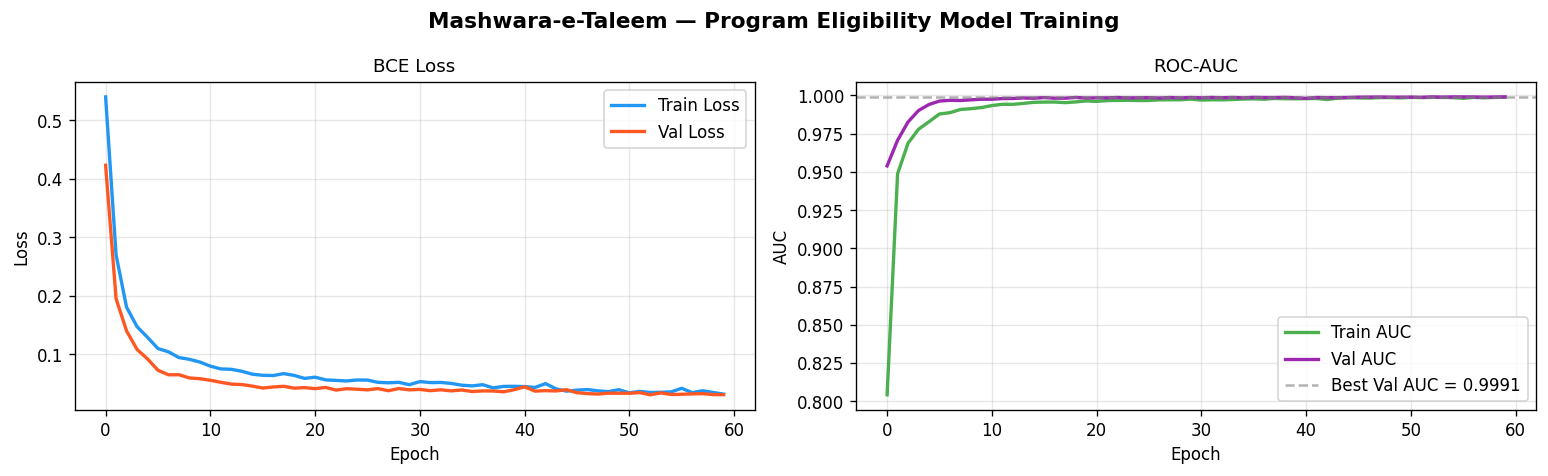

✅ Training curves saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Mashwara-e-Taleem — Program Eligibility Model Training", fontsize=13, fontweight="bold")

# Loss
axes[0].plot(history["train_loss"], label="Train Loss", linewidth=2, color="#2196F3")
axes[0].plot(history["val_loss"],   label="Val Loss",   linewidth=2, color="#FF5722")
axes[0].set_title("BCE Loss", fontsize=11)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# AUC
axes[1].plot(history["train_auc"], label="Train AUC", linewidth=2, color="#4CAF50")
axes[1].plot(history["val_auc"],   label="Val AUC",   linewidth=2, color="#9C27B0")
axes[1].axhline(y=best_val_auc, linestyle="--", color="gray", alpha=0.6, label=f"Best Val AUC = {best_val_auc:.4f}")
axes[1].set_title("ROC-AUC", fontsize=11)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_DIR / "training_curves.png", bbox_inches="tight")
plt.show()
print("✅ Training curves saved.")

📊  TEST SET EVALUATION
  ROC-AUC Score : 0.9993

              precision    recall  f1-score   support

Not Eligible       0.99      0.99      0.99      2784
    Eligible       0.97      0.96      0.97       575

    accuracy                           0.99      3359
   macro avg       0.98      0.98      0.98      3359
weighted avg       0.99      0.99      0.99      3359



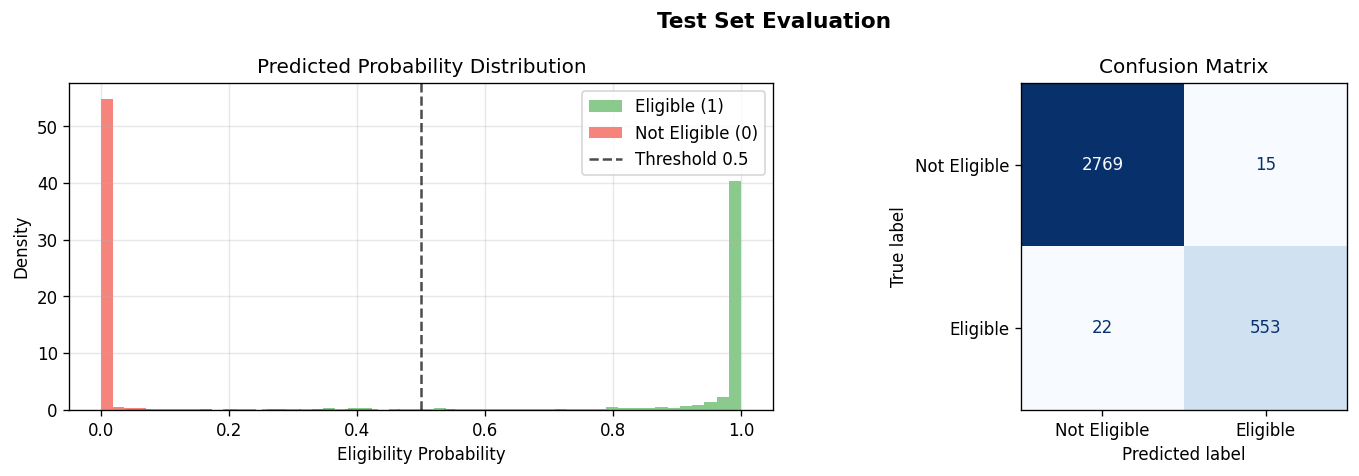

In [9]:
# Reload best checkpoint
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

all_probs_test, all_labels_test = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb.to(DEVICE))
        all_probs_test.extend(preds.cpu().numpy().tolist())
        all_labels_test.extend(yb.numpy().tolist())

all_probs_test  = np.array(all_probs_test)
all_labels_test = np.array(all_labels_test)
binary_preds    = (all_probs_test >= 0.5).astype(int)

test_auc = roc_auc_score(all_labels_test, all_probs_test)

print("=" * 55)
print("📊  TEST SET EVALUATION")
print("=" * 55)
print(f"  ROC-AUC Score : {test_auc:.4f}")
print()
print(classification_report(
    all_labels_test, binary_preds,
    target_names=["Not Eligible", "Eligible"]
))

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Test Set Evaluation", fontsize=13, fontweight="bold")

# Probability distribution
axes[0].hist(all_probs_test[all_labels_test == 1], bins=50,
             alpha=0.65, label="Eligible (1)",     color="#4CAF50", density=True)
axes[0].hist(all_probs_test[all_labels_test == 0], bins=50,
             alpha=0.65, label="Not Eligible (0)", color="#F44336", density=True)
axes[0].axvline(x=0.5, linestyle="--", color="black", alpha=0.7, label="Threshold 0.5")
axes[0].set_title("Predicted Probability Distribution")
axes[0].set_xlabel("Eligibility Probability")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Confusion matrix
cm   = confusion_matrix(all_labels_test, binary_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not Eligible", "Eligible"])
disp.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.savefig(MODEL_DIR / "evaluation.png", bbox_inches="tight")
plt.show()

In [10]:
# Encoder mappings: class_name → integer index
encoder_maps = {}
for col, le in encoders.items():
    encoder_maps[col] = {cls: int(idx) for idx, cls in enumerate(le.classes_)}

# Full metadata bundle
meta = {
    "feature_cols" : TRAIN_FEATURE_COLS,
    "encoder_maps" : encoder_maps,
    "input_dim"    : INPUT_DIM,
    "num_programs" : len(df),
    "test_auc"     : round(float(test_auc), 4),
    "scaler_mean"  : scaler.mean_.tolist(),
    "scaler_scale" : scaler.scale_.tolist(),
}

with open(META_PATH, "w") as f:
    json.dump(meta, f, indent=2)

# Programs catalog (used during batch inference)
df.to_csv(MODEL_DIR / "programs.csv", index=False)

print("✅ Artifacts saved:")
print(f"   {MODEL_PATH}         ← neural network weights")
print(f"   {META_PATH}   ← feature names, encoders, scaler")
print(f"   {MODEL_DIR / 'programs.csv'}      ← full program catalog")
print(f"\n   Test AUC: {meta['test_auc']}")
print(f"   Features: {len(TRAIN_FEATURE_COLS)}")
print(f"   Programs in catalog: {meta['num_programs']:,}")

✅ Artifacts saved:
   model_artifacts/program_eligibility_nn.pt         ← neural network weights
   model_artifacts/program_eligibility_meta.json   ← feature names, encoders, scaler
   model_artifacts/programs.csv      ← full program catalog

   Test AUC: 0.9993
   Features: 25
   Programs in catalog: 5,598


In [11]:
def _compute_final_score(eligibility_prob: float, qs_rank: int) -> float:
    """
    Blend eligibility probability (70%) with QS rank quality (30%).
    Log normalisation ensures rank #2 vs #20 matters but #800 vs #820 doesn't.
    """
    MAX_RANK = 1500
    rank_clipped = min(int(qs_rank), MAX_RANK)
    rank_quality = 1.0 - (np.log1p(rank_clipped) / np.log1p(MAX_RANK))
    return round(float(eligibility_prob) * 0.70 + rank_quality * 0.30, 4)


def _build_feature_vector(student: dict, prog: pd.Series,
                           enc_maps: dict, feat_cols: list) -> np.ndarray:
    """Build one (student, program) feature vector for inference."""

    def enc(col, val):
        return enc_maps.get(col, {}).get(str(val), 0)

    row = {
        "student_gpa"              : float(student.get("gpa", 0)),
        "student_ielts"            : float(student.get("ielts", 0)),
        "student_ielts_b"          : float(student.get("ielts_band", 0)),
        "student_toefl"            : float(student.get("toefl", 0)),
        "student_duolingo"         : float(student.get("duolingo", 0)),
        "student_gre"              : float(student.get("gre", 0)),
        "has_work_exp"             : float(student.get("has_work_exp", 0)),
        "min_gpa"                  : float(prog["min_gpa"]),
        "min_ielts_overall"        : float(prog["min_ielts_overall"]),
        "min_ielts_band"           : float(prog["min_ielts_band"]),
        "toefl_score"              : float(prog["toefl_score"]),
        "duolingo_score"           : float(prog["duolingo_score"]),
        "gre_required"             : float(prog["gre_required"]),
        "min_gre_score"            : float(prog["min_gre_score"]),
        "work_experience_required" : float(prog["work_experience_required"]),
        "program_duration_years"   : float(prog["program_duration_years"]),
        "tuition_fee_usd"          : float(prog["tuition_fee_usd"]),
        "qs_rank"                  : float(prog["qs_rank"]),
        "country_enc"              : float(enc("country",          prog["country"])),
        "program_level_enc"        : float(enc("program_level",    prog["program_level"])),
        "program_category_enc"     : float(enc("program_category", prog["program_category"])),
        "degree_type_enc"          : float(enc("degree_type",      prog["degree_type"])),
        "gpa_gap"                  : float(student.get("gpa", 0))   - float(prog["min_gpa"]),
        "ielts_gap"                : float(student.get("ielts", 0)) - float(prog["min_ielts_overall"]),
        "toefl_gap"                : float(student.get("toefl", 0)) - float(prog["toefl_score"]),
    }
    return np.array([row[c] for c in feat_cols], dtype=np.float32)


def recommend_programs(
    student: dict,
    filters: dict = None,
    top_k: int = 10,
    min_eligibility: float = 0.25,
) -> list:
    """
    Score every program in the catalog for the given student and return
    the top-k recommendations sorted by final_score.

    Parameters
    ----------
    student : dict — keys: gpa, ielts, ielts_band, toefl, duolingo, gre, has_work_exp
    filters : dict — optional keys: country (list|str), program_level, program_category,
                     degree_type, max_tuition (int), scholarship_only (bool)
    top_k           : number of results (default 10)
    min_eligibility : drop programs below this eligibility probability

    Returns
    -------
    list of dicts
    """
    # ── Load artifacts ─────────────────────────────────────────────────────
    with open(META_PATH) as f:
        meta = json.load(f)

    net = ProgramEligibilityNet(meta["input_dim"])
    net.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
    net.eval()

    programs  = pd.read_csv(MODEL_DIR / "programs.csv")
    sc_mean   = np.array(meta["scaler_mean"],  dtype=np.float32)
    sc_scale  = np.array(meta["scaler_scale"], dtype=np.float32)
    feat_cols = meta["feature_cols"]
    enc_maps  = meta["encoder_maps"]

    # ── Apply filters ───────────────────────────────────────────────────────
    progs = programs.copy()
    if filters:
        if filters.get("country"):
            countries = filters["country"] if isinstance(filters["country"], list) else [filters["country"]]
            progs = progs[progs["country"].isin(countries)]
        if filters.get("program_level"):
            progs = progs[progs["program_level"] == filters["program_level"]]
        if filters.get("program_category"):
            progs = progs[progs["program_category"] == filters["program_category"]]
        if filters.get("degree_type"):
            progs = progs[progs["degree_type"] == filters["degree_type"]]
        if filters.get("max_tuition"):
            progs = progs[progs["tuition_fee_usd"] <= int(filters["max_tuition"])]
        if filters.get("scholarship_only"):
            progs = progs[progs["scholarship_available"] == 1]

    if progs.empty:
        print("⚠️  No programs match the given filters.")
        return []

    # ── Build feature matrix (vectorised) ──────────────────────────────────
    vecs = np.stack([
        _build_feature_vector(student, row, enc_maps, feat_cols)
        for _, row in progs.iterrows()
    ])

    vecs_scaled = (vecs - sc_mean) / sc_scale
    X_tensor    = torch.tensor(vecs_scaled, dtype=torch.float32)

    # ── Inference ───────────────────────────────────────────────────────────
    with torch.no_grad():
        probs = net(X_tensor).numpy()

    # ── Collect & rank results ──────────────────────────────────────────────
    results = []
    for i, (_, prog_row) in enumerate(progs.iterrows()):
        ep = float(probs[i])
        if ep < min_eligibility:
            continue
        results.append({
            "university_name"        : prog_row["university_name"],
            "country"                : prog_row["country"],
            "qs_rank"                : int(prog_row["qs_rank"]),
            "program_name"           : prog_row["program_name"],
            "standardized_program"   : prog_row["standardized_program_name"],
            "degree_type"            : prog_row["degree_type"],
            "program_level"          : prog_row["program_level"],
            "program_category"       : prog_row["program_category"],
            "program_duration_years" : float(prog_row["program_duration_years"]),
            "tuition_fee_usd"        : int(prog_row["tuition_fee_usd"]),
            "scholarship_available"  : bool(prog_row["scholarship_available"]),
            "eligibility_prob"       : round(ep, 4),
            "final_score"            : _compute_final_score(ep, prog_row["qs_rank"]),
        })

    # Sort descending by final_score, deduplicate by (university, program)
    results.sort(key=lambda x: x["final_score"], reverse=True)
    seen, unique_results = set(), []
    for r in results:
        key = (r["university_name"], r["standardized_program"])
        if key not in seen:
            seen.add(key)
            unique_results.append(r)

    return unique_results[:top_k]

print("✅ Inference engine loaded.")

✅ Inference engine loaded.


In [12]:
# =============================================================================
#  TEST CASES — verify the model gives logical, sensible outputs
# =============================================================================

def print_recommendations(title, recs, student):
    print("\n" + "═" * 75)
    print(f"  {title}")
    print(f"  Student: GPA={student['gpa']} | IELTS={student['ielts']} | "
          f"TOEFL={student['toefl']} | GRE={student['gre']} | Work={student['has_work_exp']}")
    print("═" * 75)
    if not recs:
        print("  ⚠️  No recommendations returned.")
        return
    print(f"  {'#':<3} {'University':<32} {'Cntry':<7} {'QS':<6} "
          f"{'Degree':<7} {'Program':<28} {'Elig%':>6}  {'Score':>6}")
    print("  " + "─" * 100)
    for i, r in enumerate(recs, 1):
        print(f"  {i:<3} {r['university_name']:<32} {r['country']:<7} "
              f"{r['qs_rank']:<6} {r['degree_type']:<7} "
              f"{r['standardized_program']:<28} "
              f"{r['eligibility_prob']*100:>5.1f}%  {r['final_score']:>6.4f}")


# ─────────────────────────────────────────────────────────────────────────────
# TEST 1: Strong student — should get HIGH eligibility across top programs
# ─────────────────────────────────────────────────────────────────────────────
strong_student = {
    "gpa": 3.8, "ielts": 7.5, "ielts_band": 7.0,
    "toefl": 110, "duolingo": 130, "gre": 325, "has_work_exp": 1
}
recs_strong = recommend_programs(
    strong_student,
    filters={"program_level": "masters", "program_category": "cs"},
    top_k=5, min_eligibility=0.0
)
print_recommendations("TEST 1 — Strong Student | Masters CS", recs_strong, strong_student)

# ─────────────────────────────────────────────────────────────────────────────
# TEST 2: Weak student — should get LOW eligibility, or fewer results
# ─────────────────────────────────────────────────────────────────────────────
weak_student = {
    "gpa": 2.5, "ielts": 5.5, "ielts_band": 5.0,
    "toefl": 65, "duolingo": 80, "gre": 270, "has_work_exp": 0
}
recs_weak = recommend_programs(
    weak_student,
    filters={"program_level": "masters", "program_category": "cs"},
    top_k=5, min_eligibility=0.0
)
print_recommendations("TEST 2 — Weak Student | Masters CS", recs_weak, weak_student)

# ─────────────────────────────────────────────────────────────────────────────
# TEST 3: Average student — Business Masters in UK
# ─────────────────────────────────────────────────────────────────────────────
avg_student = {
    "gpa": 3.2, "ielts": 6.5, "ielts_band": 6.0,
    "toefl": 88, "duolingo": 105, "gre": 305, "has_work_exp": 0
}
recs_uk_business = recommend_programs(
    avg_student,
    filters={"program_level": "masters", "program_category": "business", "country": "UK"},
    top_k=5, min_eligibility=0.0
)
print_recommendations("TEST 3 — Average Student | Masters Business | UK", recs_uk_business, avg_student)

# ─────────────────────────────────────────────────────────────────────────────
# TEST 4: Scholarship-only filter — Australia Bachelors
# ─────────────────────────────────────────────────────────────────────────────
recs_scholarship = recommend_programs(
    avg_student,
    filters={"program_level": "bachelors", "country": "Australia", "scholarship_only": True},
    top_k=5, min_eligibility=0.0
)
print_recommendations("TEST 4 — Average Student | Bachelors | Australia | Scholarship Only", recs_scholarship, avg_student)

# ─────────────────────────────────────────────────────────────────────────────
# TEST 5: Sanity check — strong student should score HIGHER than weak student
# ─────────────────────────────────────────────────────────────────────────────
avg_elig_strong = np.mean([r["eligibility_prob"] for r in recs_strong]) if recs_strong else 0
avg_elig_weak   = np.mean([r["eligibility_prob"] for r in recs_weak])   if recs_weak   else 0

print("\n" + "═" * 55)
print("  ✅  SANITY CHECK SUMMARY")
print("═" * 55)
print(f"  Strong student avg eligibility : {avg_elig_strong:.2%}")
print(f"  Weak   student avg eligibility : {avg_elig_weak:.2%}")
passed = avg_elig_strong > avg_elig_weak
status = "✅ PASSED" if passed else "❌ FAILED"
print(f"  Strong > Weak?                 : {status}")
print("═" * 55)


═══════════════════════════════════════════════════════════════════════════
  TEST 1 — Strong Student | Masters CS
  Student: GPA=3.8 | IELTS=7.5 | TOEFL=110 | GRE=325 | Work=1
═══════════════════════════════════════════════════════════════════════════
  #   University                       Cntry   QS     Degree  Program                       Elig%   Score
  ────────────────────────────────────────────────────────────────────────────────────────────────────
  1   Curtin University                Australia 183    MSc     Data Science                  99.8%  0.7849
  2   Curtin University                Australia 183    MSc     Human-Computer Interaction    99.8%  0.7849
  3   University of Wollongong         Australia 184    MSc     Data Science                  99.8%  0.7847
  4   University of Wollongong         Australia 184    MSc     Software Engineering          99.8%  0.7847
  5   University of Wollongong         Australia 184    MSc     Human-Computer Interaction    99.8%  0.78

In [13]:
import pandas as pd

df = pd.read_csv("mashwara_programs_dataset_fixed.csv")

print("Program categories:")
print(df["program_category"].unique())

print("\nDegree types:")
print(df["degree_type"].unique())

print("\nProgram levels:")
print(df["program_level"].unique())

print("\nCountries:")
print(df["country"].unique())

Program categories:
['business' 'cs' 'education' 'architecture' 'arts' 'engineering'
 'social_science' 'health' 'law' 'science']

Degree types:
['BSc' 'BCom' 'BBA' 'BEng' 'BA' 'BEd' 'BDes' 'BArch' 'MA' 'MSc' 'MEd'
 'LLB' 'BN' 'LLM' 'MFA' 'MDes' 'BFA' 'MArch' 'BPharm' 'MBA' 'MEng' 'MPH']

Program levels:
['bachelors' 'masters']

Countries:
['UK' 'Australia' 'Germany' 'Canada' 'Qatar']


In [14]:
%%writefile app.py

import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from typing import Optional, List

from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel, Field


# ── Model definition ──────────────────────────────────────────────────────────
class ProgramEligibilityNet(nn.Module):
    def __init__(self, input_dim: int, dropout1: float = 0.3, dropout2: float = 0.2):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout1),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout1),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(dropout2),
            nn.Linear(64, 32),         nn.ReLU(),
            nn.Linear(32, 1),          nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x).squeeze(1)


# ── Load artifacts at startup ─────────────────────────────────────────────────
MODEL_DIR  = Path("model_artifacts")
META_PATH  = MODEL_DIR / "program_eligibility_meta.json"
MODEL_PATH = MODEL_DIR / "program_eligibility_nn.pt"

with open(META_PATH) as f:
    META = json.load(f)

NET = ProgramEligibilityNet(META["input_dim"])
NET.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
NET.eval()

PROGRAMS  = pd.read_csv(MODEL_DIR / "programs.csv")
SC_MEAN   = np.array(META["scaler_mean"],  dtype=np.float32)
SC_SCALE  = np.array(META["scaler_scale"], dtype=np.float32)
FEAT_COLS = META["feature_cols"]
ENC_MAPS  = META["encoder_maps"]


# ── Pydantic schemas ──────────────────────────────────────────────────────────
class StudentProfile(BaseModel):
    gpa          : float = Field(..., ge=0.0, le=4.0,  description="GPA on 4.0 scale")
    ielts        : float = Field(0.0, ge=0.0, le=9.0,  description="IELTS Overall band")
    ielts_band   : float = Field(0.0, ge=0.0, le=9.0,  description="IELTS min band score")
    toefl        : int   = Field(0,   ge=0,   le=120,  description="TOEFL iBT total")
    duolingo     : int   = Field(0,   ge=0,   le=160,  description="Duolingo score")
    gre          : int   = Field(0,   ge=0,   le=340,  description="GRE total score")
    has_work_exp : int   = Field(0,   ge=0,   le=1,    description="Work experience (0/1)")


class RecommendationFilters(BaseModel):
    country           : Optional[List[str]] = None
    program_level     : Optional[str]       = None
    program_category  : Optional[str]       = None
    degree_type       : Optional[str]       = None
    max_tuition       : Optional[int]       = None
    scholarship_only  : bool                = False


class RecommendationRequest(BaseModel):
    student         : StudentProfile
    filters         : Optional[RecommendationFilters] = None
    top_k           : int   = Field(10, ge=1, le=50)
    min_eligibility : float = Field(0.25, ge=0.0, le=1.0)


class ProgramResult(BaseModel):
    university_name         : str
    country                 : str
    qs_rank                 : int
    program_name            : str
    standardized_program    : str
    degree_type             : str
    program_level           : str
    program_category        : str
    program_duration_years  : float
    tuition_fee_usd         : int
    scholarship_available   : bool
    eligibility_prob        : float
    final_score             : float


class RecommendationResponse(BaseModel):
    total_programs_scored : int
    results_returned      : int
    recommendations       : List[ProgramResult]


# ── Utility ───────────────────────────────────────────────────────────────────
def _enc(col: str, val) -> float:
    return float(ENC_MAPS.get(col, {}).get(str(val), 0))


def _build_vec(student: dict, prog: pd.Series) -> np.ndarray:
    row = {
        "student_gpa"              : float(student["gpa"]),
        "student_ielts"            : float(student["ielts"]),
        "student_ielts_b"          : float(student["ielts_band"]),
        "student_toefl"            : float(student["toefl"]),
        "student_duolingo"         : float(student["duolingo"]),
        "student_gre"              : float(student["gre"]),
        "has_work_exp"             : float(student["has_work_exp"]),
        "min_gpa"                  : float(prog["min_gpa"]),
        "min_ielts_overall"        : float(prog["min_ielts_overall"]),
        "min_ielts_band"           : float(prog["min_ielts_band"]),
        "toefl_score"              : float(prog["toefl_score"]),
        "duolingo_score"           : float(prog["duolingo_score"]),
        "gre_required"             : float(prog["gre_required"]),
        "min_gre_score"            : float(prog["min_gre_score"]),
        "work_experience_required" : float(prog["work_experience_required"]),
        "program_duration_years"   : float(prog["program_duration_years"]),
        "tuition_fee_usd"          : float(prog["tuition_fee_usd"]),
        "qs_rank"                  : float(prog["qs_rank"]),
        "country_enc"              : _enc("country",          prog["country"]),
        "program_level_enc"        : _enc("program_level",    prog["program_level"]),
        "program_category_enc"     : _enc("program_category", prog["program_category"]),
        "degree_type_enc"          : _enc("degree_type",      prog["degree_type"]),
        "gpa_gap"                  : float(student["gpa"])   - float(prog["min_gpa"]),
        "ielts_gap"                : float(student["ielts"]) - float(prog["min_ielts_overall"]),
        "toefl_gap"                : float(student["toefl"]) - float(prog["toefl_score"]),
    }
    return np.array([row[c] for c in FEAT_COLS], dtype=np.float32)


def _final_score(elig: float, qs_rank: int) -> float:
    rank_quality = 1.0 - (np.log1p(min(int(qs_rank), 1500)) / np.log1p(1500))
    return round(elig * 0.70 + rank_quality * 0.30, 4)


# ── FastAPI app ───────────────────────────────────────────────────────────────
app = FastAPI(
    title       = "Mashwara-e-Taleem — Program Eligibility API",
    description = "Ranks non-US university programs by eligibility probability × QS ranking.",
    version     = "1.0.0",
)

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"], allow_methods=["*"], allow_headers=["*"],
)


@app.get("/", tags=["Health"])
def health_check():
    return {
        "status"              : "running",
        "model"               : "Program Eligibility Neural Network",
        "programs_in_catalog" : int(META["num_programs"]),
        "test_roc_auc"        : META["test_auc"],
        "feature_count"       : len(FEAT_COLS),
    }


@app.get("/catalog/meta", tags=["Catalog"])
def catalog_metadata():
    """Returns all available filter values for the frontend dropdowns."""
    return {
        "countries"          : sorted(PROGRAMS["country"].unique().tolist()),
        "program_levels"     : sorted(PROGRAMS["program_level"].unique().tolist()),
        "program_categories" : sorted(PROGRAMS["program_category"].unique().tolist()),
        "degree_types"       : sorted(PROGRAMS["degree_type"].unique().tolist()),
        "total_programs"     : int(len(PROGRAMS)),
    }


@app.post("/recommend", response_model=RecommendationResponse, tags=["Recommendations"])
def get_recommendations(req: RecommendationRequest):
    """
    Given a student's academic profile, returns top-k program recommendations
    ranked by eligibility probability combined with QS world ranking.
    """
    student = req.student.dict()
    filters = req.filters.dict() if req.filters else {}

    # ── Filter catalog ────────────────────────────────────────────────────
    progs = PROGRAMS.copy()
    if filters.get("country"):
        c = filters["country"]
        progs = progs[progs["country"].isin(c if isinstance(c, list) else [c])]
    if filters.get("program_level"):
        progs = progs[progs["program_level"] == filters["program_level"]]
    if filters.get("program_category"):
        progs = progs[progs["program_category"] == filters["program_category"]]
    if filters.get("degree_type"):
        progs = progs[progs["degree_type"] == filters["degree_type"]]
    if filters.get("max_tuition"):
        progs = progs[progs["tuition_fee_usd"] <= int(filters["max_tuition"])]
    if filters.get("scholarship_only"):
        progs = progs[progs["scholarship_available"] == 1]

    if progs.empty:
        raise HTTPException(status_code=404, detail="No programs match the applied filters.")

    total_scored = len(progs)

    # ── Score all programs ────────────────────────────────────────────────
    vecs        = np.stack([_build_vec(student, row) for _, row in progs.iterrows()])
    vecs_scaled = (vecs - SC_MEAN) / SC_SCALE
    X_t         = torch.tensor(vecs_scaled, dtype=torch.float32)

    with torch.no_grad():
        probs = NET(X_t).numpy()

    # ── Build response ────────────────────────────────────────────────────
    results = []
    for i, (_, prog_row) in enumerate(progs.iterrows()):
        ep = float(probs[i])
        if ep < req.min_eligibility:
            continue
        results.append({
            "university_name"        : prog_row["university_name"],
            "country"                : prog_row["country"],
            "qs_rank"                : int(prog_row["qs_rank"]),
            "program_name"           : prog_row["program_name"],
            "standardized_program"   : prog_row["standardized_program_name"],
            "degree_type"            : prog_row["degree_type"],
            "program_level"          : prog_row["program_level"],
            "program_category"       : prog_row["program_category"],
            "program_duration_years" : float(prog_row["program_duration_years"]),
            "tuition_fee_usd"        : int(prog_row["tuition_fee_usd"]),
            "scholarship_available"  : bool(prog_row["scholarship_available"]),
            "eligibility_prob"       : round(ep, 4),
            "final_score"            : _final_score(ep, prog_row["qs_rank"]),
        })

    results.sort(key=lambda x: x["final_score"], reverse=True)
    seen, unique_results = set(), []
    for r in results:
        key = (r["university_name"], r["standardized_program"])
        if key not in seen:
            seen.add(key)
            unique_results.append(r)
    unique_results = unique_results[:req.top_k]

    return RecommendationResponse(
        total_programs_scored = total_scored,
        results_returned      = len(unique_results),
        recommendations       = [ProgramResult(**r) for r in unique_results],
    )

Writing app.py


In [15]:
# !wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
# !chmod +x cloudflared-linux-amd64

In [16]:
# import nest_asyncio
# import uvicorn
# from app import app

# nest_asyncio.apply()

# import threading

# def run():
#     uvicorn.run(app, host="0.0.0.0", port=8000)

# threading.Thread(target=run).start()

In [17]:
# ─────────────────────────────────────────────────────────────
# CELL 1 — START FASTAPI + CLOUDFLARE TUNNEL
# ─────────────────────────────────────────────────────────────

!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64

import nest_asyncio
import uvicorn
import threading
import subprocess
import re
import time

from app import app

nest_asyncio.apply()

# ── Run FastAPI in background ────────────────────────────────
def run():
    uvicorn.run(app, host="0.0.0.0", port=8000)

threading.Thread(target=run).start()

time.sleep(2)

# ── Start Cloudflare tunnel ──────────────────────────────────
process = subprocess.Popen(
    ["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8000"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

url = None
for _ in range(50):
    line = process.stdout.readline()
    print(line.strip())

    match = re.search(r"(https://.*?\.trycloudflare\.com)", line)
    if match:
        url = match.group(1)
        break

# Save URL for next cell
with open("api_url.txt", "w") as f:
    f.write(url)

print("\n" + "="*60)
print(f"🚀 API LIVE: {url}")
print(f"📖 Docs: {url}/docs")
print("="*60)

INFO:     Started server process [4488]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


2026-04-01T11:24:05Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-04-01T11:24:05Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-04-01T11:24:08Z INF +--------------------------------------------------------------------------------------------+
2026-04-01T11:24:08Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-04-01T11:24:08Z INF |  https://applicable-brian-operated-nissan.trycloudflar

In [19]:
# ─────────────────────────────────────────────────────────────
# CELL 2 — FULL API TEST SUITE
# Run this IMMEDIATELY after Cell 1 — tunnel URL expires on restart
# ─────────────────────────────────────────────────────────────

import requests
import json
import time

# ── Read the FRESH URL saved by Cell 1 ───────────────────────
try:
    with open("api_url.txt") as f:
        BASE = f.read().strip()
    print(f"✅ Using API URL: {BASE}")
except FileNotFoundError:
    raise RuntimeError("❌ api_url.txt not found — run Cell 1 first!")

# ── Give the tunnel a moment to stabilise ────────────────────
print("⏳ Waiting for tunnel to stabilise...")
time.sleep(5)


# ─────────────────────────────────────────────────────────────
# Helper printer
# ─────────────────────────────────────────────────────────────
def pretty_print_response(title, response):
    print("\n" + "═" * 72)
    print(f"  {title}")
    print("═" * 72)

    if response.status_code != 200:
        print(f"  ❌ HTTP {response.status_code}: {response.text[:300]}")
        return

    data = response.json()

    if "recommendations" in data:
        print(f"  Programs scored  : {data['total_programs_scored']}")
        print(f"  Results returned : {data['results_returned']}")
        print()
        print(f"  {'#':<3} {'University':<32} {'QS':>5}  {'Degree':<6}  "
              f"{'Program':<26}  {'Elig%':>6}  {'Score':>6}")
        print("  " + "─" * 92)
        for i, r in enumerate(data["recommendations"], 1):
            print(f"  {i:<3} {r['university_name']:<32} {r['qs_rank']:>5}  "
                  f"{r['degree_type']:<6}  {r['standardized_program']:<26}  "
                  f"{r['eligibility_prob']*100:>5.1f}%  {r['final_score']:>6.4f}")
    else:
        print(json.dumps(data, indent=2))


# ─────────────────────────────────────────────────────────────
# Safe request wrapper — handles connection errors gracefully
# ─────────────────────────────────────────────────────────────
def safe_get(url, **kwargs):
    try:
        return requests.get(url, timeout=30, **kwargs)
    except requests.exceptions.ConnectionError as e:
        print(f"\n❌ Connection failed: tunnel may have expired. Re-run Cell 1.\n{e}")
        return None

def safe_post(url, **kwargs):
    try:
        return requests.post(url, timeout=30, **kwargs)
    except requests.exceptions.ConnectionError as e:
        print(f"\n❌ Connection failed: tunnel may have expired. Re-run Cell 1.\n{e}")
        return None


# ─────────────────────────────────────────────────────────────
# API TEST 1 — Health Check
# Expected: status=running, model info, AUC
# ─────────────────────────────────────────────────────────────
r = safe_get(f"{BASE}/")
if r: pretty_print_response("API TEST 1 — Health Check", r)


# ─────────────────────────────────────────────────────────────
# API TEST 2 — Catalog Metadata
# Expected: countries, levels, categories, degree types, total_programs
# ─────────────────────────────────────────────────────────────
r = safe_get(f"{BASE}/catalog/meta")
if r: pretty_print_response("API TEST 2 — Catalog Metadata", r)


# ─────────────────────────────────────────────────────────────
# API TEST 3 — Strong Student | Masters CS
# Expected: HIGH eligibility (>80%), top ranked universities
# ─────────────────────────────────────────────────────────────
payload_strong = {
    "student": {
        "gpa": 3.8, "ielts": 7.5, "ielts_band": 7.0,
        "toefl": 110, "duolingo": 130, "gre": 325, "has_work_exp": 1
    },
    "filters": {"program_level": "masters", "program_category": "cs"},
    "top_k": 5,
    "min_eligibility": 0.0
}
r = safe_post(f"{BASE}/recommend", json=payload_strong)
if r: pretty_print_response("API TEST 3 — Strong Student | Masters CS", r)


# ─────────────────────────────────────────────────────────────
# API TEST 4 — Weak Student | Masters CS
# Expected: LOW eligibility (<20%), model should still return results
# ─────────────────────────────────────────────────────────────
payload_weak = {
    "student": {
        "gpa": 2.5, "ielts": 5.5, "ielts_band": 5.0,
        "toefl": 60, "duolingo": 80, "gre": 270, "has_work_exp": 0
    },
    "filters": {"program_level": "masters", "program_category": "cs"},
    "top_k": 5,
    "min_eligibility": 0.0
}
r = safe_post(f"{BASE}/recommend", json=payload_weak)
if r: pretty_print_response("API TEST 4 — Weak Student | Masters CS", r)


# ─────────────────────────────────────────────────────────────
# API TEST 5 — UK Business Masters + Scholarship Only
# Expected: UK universities only, scholarship_available=True
# ─────────────────────────────────────────────────────────────
r = safe_post(f"{BASE}/recommend", json={
    "student": {
        "gpa": 3.2, "ielts": 6.5, "ielts_band": 6.0,
        "toefl": 88, "duolingo": 105, "gre": 305, "has_work_exp": 0
    },
    "filters": {
        "country": ["UK"],
        "program_level": "masters",
        "program_category": "business",
        "scholarship_only": True
    },
    "top_k": 5,
    "min_eligibility": 0.0
})
if r: pretty_print_response("API TEST 5 — UK Business Masters + Scholarship", r)


# ─────────────────────────────────────────────────────────────
# API TEST 6 — Budget Filter (max tuition $30,000)
# Expected: all returned programs have tuition_fee_usd <= 30000
# ─────────────────────────────────────────────────────────────
r = safe_post(f"{BASE}/recommend", json={
    "student": {
        "gpa": 3.4, "ielts": 6.5, "ielts_band": 6.0,
        "toefl": 90, "duolingo": 110, "gre": 310, "has_work_exp": 0
    },
    "filters": {"program_level": "masters", "max_tuition": 30000},
    "top_k": 5,
    "min_eligibility": 0.0
})
if r: pretty_print_response("API TEST 6 — Budget Student | Max Tuition $30k", r)


# ─────────────────────────────────────────────────────────────
# FINAL SANITY CHECK
# Strong student MUST score higher than weak student — always
# ─────────────────────────────────────────────────────────────
def get_avg_score(payload):
    r = safe_post(f"{BASE}/recommend", json=payload)
    if r and r.status_code == 200:
        recs = r.json().get("recommendations", [])
        return sum(x["final_score"] for x in recs) / len(recs) if recs else 0.0
    return 0.0

avg_strong = get_avg_score(payload_strong)
avg_weak   = get_avg_score(payload_weak)
passed     = avg_strong > avg_weak

print("\n" + "═" * 55)
print("  ✅  FINAL SANITY CHECK")
print("═" * 55)
print(f"  Strong student avg score : {avg_strong:.4f}")
print(f"  Weak   student avg score : {avg_weak:.4f}")
print(f"  Strong > Weak?           : {'✅ PASSED' if passed else '❌ FAILED'}")
print("═" * 55)

✅ Using API URL: https://applicable-brian-operated-nissan.trycloudflare.com
⏳ Waiting for tunnel to stabilise...
INFO:     136.109.64.221:0 - "GET / HTTP/1.1" 200 OK

════════════════════════════════════════════════════════════════════════
  API TEST 1 — Health Check
════════════════════════════════════════════════════════════════════════
{
  "status": "running",
  "model": "Program Eligibility Neural Network",
  "programs_in_catalog": 5598,
  "test_roc_auc": 0.9993,
  "feature_count": 25
}
INFO:     136.109.64.221:0 - "GET /catalog/meta HTTP/1.1" 200 OK

════════════════════════════════════════════════════════════════════════
  API TEST 2 — Catalog Metadata
════════════════════════════════════════════════════════════════════════
{
  "countries": [
    "Australia",
    "Canada",
    "Germany",
    "Qatar",
    "UK"
  ],
  "program_levels": [
    "bachelors",
    "masters"
  ],
  "program_categories": [
    "architecture",
    "arts",
    "business",
    "cs",
    "education",
    "engi

In [20]:
import shutil
import os

# Zip the entire model_artifacts folder
shutil.make_archive("mashwara_model_artifacts", "zip", "model_artifacts")

# Download to your local machine
from google.colab import files
files.download("mashwara_model_artifacts.zip")

print("✅ Downloaded: mashwara_model_artifacts.zip")
print("\nContents:")
for f in sorted(os.listdir("model_artifacts")):
    size = os.path.getsize(f"model_artifacts/{f}")
    print(f"  {f:<45} {size/1024:.1f} KB")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: mashwara_model_artifacts.zip

Contents:
  evaluation.png                                49.4 KB
  program_eligibility_meta.json                 2.6 KB
  program_eligibility_nn.pt                     211.0 KB
  programs.csv                                  1223.8 KB
  training_curves.png                           73.9 KB
